<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Transformers/transformer_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import warnings
warnings.filterwarnings("ignore")

#Using Default Models

In [1]:
import torch
torch.__version__

'2.10.0+cpu'

### Sentiment analyzer

In [4]:
from transformers import pipeline

In [5]:
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [10]:
result = classifier("I don't rate lukaku one bit")
result

[{'label': 'NEGATIVE', 'score': 0.9926869869232178}]

### image segmentation

In [26]:
obj_segmentation = pipeline("image-segmentation")

No model was supplied, defaulted to facebook/detr-resnet-50-panoptic and revision d53b52a.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/172M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/562 [00:00<?, ?it/s]

DetrForSegmentation LOAD REPORT from: facebook/detr-resnet-50-panoptic
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
detr.model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
detr.model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
detr.model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
detr.model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

In [27]:
result = obj_segmentation("/content/alotgoingon.jpg")

`label_ids_to_fuse` unset. No instance will be fused.


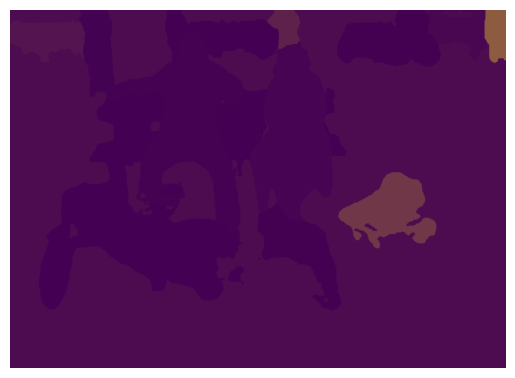

In [37]:
import matplotlib.pyplot as plt
import numpy as np

for obj in result:
    mask = np.array(obj["mask"])
    plt.imshow(mask, alpha=0.4)

plt.axis("off")
plt.show()

### Img classification

In [38]:
img_classifier = pipeline("image-classification")

No model was supplied, defaulted to google/vit-base-patch16-224 and revision 3f49326.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


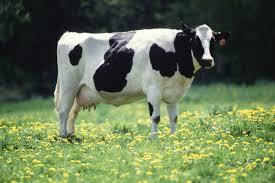

In [43]:
from PIL import Image

Image.open("/content/images (3).jpg")

In [41]:
result = img_classifier("/content/images (3).jpg")

In [42]:
result

[{'label': 'ox', 'score': 0.9338552951812744},
 {'label': 'oxcart', 'score': 0.018042853102087975},
 {'label': 'milk can', 'score': 0.0015566108049824834},
 {'label': 'water buffalo, water ox, Asiatic buffalo, Bubalus bubalis',
  'score': 0.0012986869551241398},
 {'label': 'worm fence, snake fence, snake-rail fence, Virginia fence',
  'score': 0.0011868843575939536}]

### NER

In [50]:
NER = pipeline("ner")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [51]:
docs = "There is a huge eruptiotion in Mt Kenya, KCB has been Dishing Projects in Githurai, Mwiki and Roysambu, headed by Silas Jirongo"
result = NER(docs)

In [52]:
result

[{'entity': 'I-LOC',
  'score': np.float32(0.69890547),
  'index': 10,
  'word': 'Mt',
  'start': 31,
  'end': 33},
 {'entity': 'I-LOC',
  'score': np.float32(0.99769956),
  'index': 11,
  'word': 'Kenya',
  'start': 34,
  'end': 39},
 {'entity': 'I-ORG',
  'score': np.float32(0.9992675),
  'index': 13,
  'word': 'KC',
  'start': 41,
  'end': 43},
 {'entity': 'I-ORG',
  'score': np.float32(0.9949532),
  'index': 14,
  'word': '##B',
  'start': 43,
  'end': 44},
 {'entity': 'I-LOC',
  'score': np.float32(0.9789619),
  'index': 21,
  'word': 'G',
  'start': 74,
  'end': 75},
 {'entity': 'I-LOC',
  'score': np.float32(0.9106316),
  'index': 22,
  'word': '##ith',
  'start': 75,
  'end': 78},
 {'entity': 'I-LOC',
  'score': np.float32(0.96022797),
  'index': 23,
  'word': '##urai',
  'start': 78,
  'end': 82},
 {'entity': 'I-LOC',
  'score': np.float32(0.96820325),
  'index': 25,
  'word': 'M',
  'start': 84,
  'end': 85},
 {'entity': 'I-LOC',
  'score': np.float32(0.9630202),
  'index': 2